In [9]:
import torch
import qewton
import matplotlib.pyplot as plt

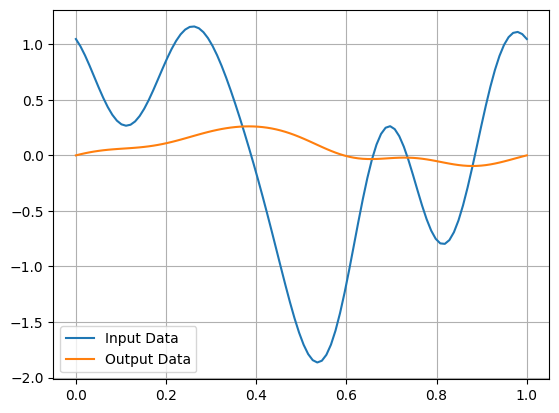

In [10]:
input_data = torch.load("../data/integrator/f_data.pt", weights_only=True)
output_data = torch.load("../data/integrator/u_data.pt", weights_only=True)
x_data = torch.load("../data/integrator/x_data.pt", weights_only=True)
x_data = torch.repeat_interleave(x_data.unsqueeze(0), repeats=5000, dim=0)

train_in_data, train_out_data, train_x_data = input_data[:4000], output_data[:4000], x_data[:4000]
test_in_data, test_out_data, test_x_data = input_data[4000:], output_data[4000:], x_data[4000:]

batch_size = 1000

plt.plot(x_data[0], input_data[0].numpy(), label="Input Data")
plt.plot(x_data[0], output_data[0].numpy(), label="Output Data")
plt.grid()
plt.legend()

In [11]:
F = qewton.config.Variable("f", 1)
X = qewton.config.Variable("x", 1)
U = qewton.config.Variable("u", 1)

dataset = qewton.data.GridDataSet(
    data=[train_in_data, train_x_data, train_out_data], 
    feature_variables=[F, X, U],
    geometry_variable=X
)
test_dataset = qewton.data.GridDataSet(
    data=[test_in_data, test_x_data, test_out_data],
    feature_variables=[F, X, U],
    geometry_variable=X
)

In [12]:
data_loader = qewton.data.DataLoader(
    data_set=dataset,
    test_data_set=test_dataset,
    batch_size=batch_size,
    splitting_ratio=(1.0, 0.0, 0.0),
    shuffle_data=False,
)

In [13]:
model = qewton.algorithms.FCNDeepONet(
    trunk_input=X, 
    branch_input=F,
    output=U,
    trunk_hidden_neurons=16,
    branch_hidden_neurons=16,
    trunk_hidden_layers=3,
    branch_hidden_layers=2,
    intermediate_neurons=32,
)

In [14]:
constraint = qewton.constraints.MSEConstraint()
computation_graph = qewton.Graph()
computation_graph.connect(data_loader.get_output_port(F), model.branch_port)
computation_graph.connect(data_loader.get_output_port(X), model.trunk_port)
computation_graph.connect(model, constraint.input_1)
computation_graph.connect(data_loader.get_output_port(U), constraint.input_2)

In [15]:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.001,
    max_iterations=2500,
)

trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase],
    graphs=[computation_graph],
    training_objectives=[constraint],
    device="cuda:0",
)

trainer.run()

Optimization Phase 1: 100%|██████████| 2500/2500 [01:23<00:00, 30.04it/s, loss=0.000562]


In [17]:
import plotly.io as pio
pio.renderers.default = "vscode"

from qewton.visualization import Figure

u_config = data_loader.get_output_port(U).get_data_configuration(computation_graph)
layout = computation_graph.visualize(
    model.output_ports[0],
    reference=data_loader.get_output_port(U),
    prediction_config=u_config,
    mode=qewton.optim.EvaluationPhase.TRAIN,
)
Figure(layout).show()